In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
import joblib

In [29]:
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

Saving EnviroBirth PreBEnvBD Dataset-Driven Prediction.csv to EnviroBirth PreBEnvBD Dataset-Driven Prediction (1).csv


In [30]:

df = pd.read_csv(list(uploaded.keys())[0])

print("Shape:", df.shape)
print("Columns:", df.columns)
df.head()

Shape: (73000, 59)
Columns: Index(['Address', 'Latitude', 'Longitude', 'SO2', 'NO2', 'CO', 'O3', 'PM2.5',
       'PM10', 'CASEID', 'BIDX', 'Birth_Order', 'Multiple_Birth',
       'Preceding_Birth_Interval', 'Succeeding_Birth_Interval',
       'Gestational_Duration', 'Mother_Age', 'Education', 'Wealth_Index',
       'Drinking_Water_Source', 'Toilet_Type', 'Electricity', 'Cooking_Fuel',
       'Usual_Residents', 'Sleeping_Rooms', 'Place_of_Delivery',
       'Multiple_Birth.1', 'Child_Alive', 'Age_at_Death_Days',
       'Age_at_Death_Months', 'Gestation_Months', 'Pregnancy_Duration',
       'Birth_Size_Reported', 'Birth_Weight_Reported', 'Mother_Age.1',
       'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Delivery_Assistance',
       'Csection_Delivery', 'Iron_Supplement', 'BP_Checked', 'Urine_Test',
       'Blood_Test', 'Ultrasound', 'Weight_Measured', 'Height_Measured',
       'Stomach_Exam', 'Fetal_heartbeat', 'Blood_Pressure_Test',
       'Cooking_Location', 'Separate_Kitchen', 'Ha

,Address,Latitude,Longitude,SO2,NO2,CO,O3,PM2.5,PM10,CASEID,...,Blood_Pressure_Test,Cooking_Location,Separate_Kitchen,Has_Mosquito_Net,Number_Mosquito_Nets,Children_Using_Nets,Rainfall,Humidity,Temperature,Preterm
0,"Uttara, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.059,1.2,0.0525,57,73,0100 1 4,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,78.0,20.1,0
1,"Jatrabari, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.058,1.2,0.0525,59,71,0100 11 1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,79.0,21.0,1
2,"Kuril Bishow Road, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.056,1.2,0.0525,59,70,0102 3 2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,82.0,20.1,0
3,"Mohakhali, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.056,1.2,0.0525,58,70,0102 8 1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,73.0,21.0,0
4,"Dhanmondi, Dhaka, Bangladesh)",23.820612,90.421011,0.03,0.051,1.2,0.0525,61,69,0104 4 2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,67.0,20.3,0


In [31]:
env_features = ["SO2","NO2","CO","O3","PM2.5","PM10","Rainfall","Humidity","Temperature"]
maternal_features = ["Mother_Age","Mother_Height","Mother_Weight","Mother_BMI","Gestation_Months","Birth_Weight_Reported"]
household_features = ["Education","Wealth_Index","Drinking_Water_Source","Toilet_Type","Cooking_Fuel","Cooking_Location","Separate_Kitchen","Electricity","Has_Mosquito_Net"]
drop_cols = ["CASEID","BIDX","Address","Latitude","Longitude"]
features = env_features + maternal_features + household_features


In [32]:
selected = [c for c in (env_features + maternal_features + household_features) if c in df.columns]
print("Selected features (will use):", selected)
target = "Preterm"
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in df.columns")

Selected features (will use): ['SO2', 'NO2', 'CO', 'O3', 'PM2.5', 'PM10', 'Rainfall', 'Humidity', 'Temperature', 'Mother_Age', 'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Gestation_Months', 'Birth_Weight_Reported', 'Education', 'Wealth_Index', 'Drinking_Water_Source', 'Toilet_Type', 'Cooking_Fuel', 'Cooking_Location', 'Separate_Kitchen', 'Electricity', 'Has_Mosquito_Net']


In [33]:

print("Unique target values:", df[target].unique())

if df[target].dtype == 'object' or df[target].dtype.name == 'category':
    tmp = df[target].astype(str).str.strip().str.lower()
    if set(tmp.unique()).issubset({'yes','no','y','n'}):
        df[target] = tmp.map({'yes':1,'y':1,'no':0,'n':0})
    else:
        le_target = LabelEncoder()
        df[target] = le_target.fit_transform(df[target].astype(str))
print("After encode, target dtype:", df[target].dtype)


Unique target values: [0 1]
After encode, target dtype: int64


In [34]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

print("--- Preprocessing before SMOTE ---")

# NEW STEP: Detect and drop columns that are 100% missing
empty_cols = X_train.columns[X_train.isna().all()].tolist()
if empty_cols:
    print(f"Dropping 100% empty columns: {empty_cols}")
    X_train = X_train.drop(columns=empty_cols)
    X_test = X_test.drop(columns=empty_cols)

# 1. Separate numeric and categorical columns
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

# 2. Impute (fill) missing values
if num_cols:
    num_imputer = SimpleImputer(strategy='median')
    X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
    X_test[num_cols] = num_imputer.transform(X_test[num_cols])

if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

    # 3. Encode categorical text into numbers
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
    X_test[cat_cols] = encoder.transform(X_test[cat_cols])

print("Missing values handled and categoricals encoded. Ready for SMOTE.")

--- Preprocessing before SMOTE ---
Missing values handled and categoricals encoded. Ready for SMOTE.


In [35]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# ---------------------------------------------------------
# 1. SPLIT THE DATA
# ---------------------------------------------------------
X = df[selected].copy()
y = df[target].copy()

print("Class balance before split:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Shapes -> X_train:", X_train.shape, "X_test:", X_test.shape)

# ---------------------------------------------------------
# 2. PREPROCESS (Clean NaNs and Text)
# ---------------------------------------------------------
print("\n--- Preprocessing before SMOTE ---")
# Drop completely empty columns
empty_cols = X_train.columns[X_train.isna().all()].tolist()
if empty_cols:
    print(f"Dropping 100% empty columns: {empty_cols}")
    X_train = X_train.drop(columns=empty_cols)
    X_test = X_test.drop(columns=empty_cols)

num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

# Fill missing numbers with median
if num_cols:
    num_imputer = SimpleImputer(strategy='median')
    X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
    X_test[num_cols] = num_imputer.transform(X_test[num_cols])

# Fill missing text with most frequent, then encode to numbers
if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    # Using .astype(str) to prevent mixed-type errors during encoding
    X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols].astype(str))
    X_test[cat_cols] = encoder.transform(X_test[cat_cols].astype(str))

# ---------------------------------------------------------
# 3. APPLY SMOTE
# ---------------------------------------------------------
print("\nBefore SMOTE:\n", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", y_train.value_counts())

Class balance before split:
 Preterm
0    67334
1     5666
Name: count, dtype: int64
Shapes -> X_train: (58400, 24) X_test: (14600, 24)

--- Preprocessing before SMOTE ---
Dropping 100% empty columns: ['Birth_Weight_Reported']

Before SMOTE:
 Preterm
0    53867
1     4533
Name: count, dtype: int64
After SMOTE:
 Preterm
0    53867
1    53867
Name: count, dtype: int64


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# THE FIX: Check the current X_train.columns instead of the old 'selected' list
numeric_feats = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_feats = [c for c in X_train.columns if c not in numeric_feats]

print("Numeric:", numeric_feats)
print("Categorical:", categorical_feats)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

transformers = [('num', numeric_transformer, numeric_feats)]

if len(categorical_feats) > 0:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    transformers.append(('cat', categorical_transformer, categorical_feats))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print("Transformed shapes:", X_train_t.shape, X_test_t.shape)

Numeric: ['SO2', 'NO2', 'CO', 'O3', 'PM2.5', 'PM10', 'Rainfall', 'Humidity', 'Temperature', 'Mother_Age', 'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Gestation_Months', 'Education', 'Wealth_Index', 'Drinking_Water_Source', 'Toilet_Type', 'Cooking_Fuel', 'Cooking_Location', 'Separate_Kitchen', 'Electricity', 'Has_Mosquito_Net']
Categorical: []
Transformed shapes: (107734, 23) (14600, 23)


In [37]:

from sklearn.neural_network import MLPClassifier


mlp_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(64,32),
        activation='relu',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        verbose=True
    ))
])


In [38]:

mlp_model.fit(X_train, y_train)
clf = mlp_model.named_steps['classifier']


Iteration 1, loss = 0.56450378
Validation score: 0.721459
Iteration 2, loss = 0.50541507
Validation score: 0.741136
Iteration 3, loss = 0.48296145
Validation score: 0.752645
Iteration 4, loss = 0.47060377
Validation score: 0.758864
Iteration 5, loss = 0.46148644
Validation score: 0.756079
Iteration 6, loss = 0.45475971
Validation score: 0.766104
Iteration 7, loss = 0.44860644
Validation score: 0.768424
Iteration 8, loss = 0.44332003
Validation score: 0.770095
Iteration 9, loss = 0.43872135
Validation score: 0.772786
Iteration 10, loss = 0.43490895
Validation score: 0.778355
Iteration 11, loss = 0.43136855
Validation score: 0.775756
Iteration 12, loss = 0.42787892
Validation score: 0.784110
Iteration 13, loss = 0.42491186
Validation score: 0.778355
Iteration 14, loss = 0.42144811
Validation score: 0.782903
Iteration 15, loss = 0.41800674
Validation score: 0.787915
Iteration 16, loss = 0.41491624
Validation score: 0.788472
Iteration 17, loss = 0.41276791
Validation score: 0.785688
Iterat

In [39]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# Changed path to the local /content/ folder
pdf_path = '/content/MLP_training_report.pdf'

with PdfPages(pdf_path) as pdf:
    plt.figure(figsize=(8,5))
    # Assuming 'clf' is your trained MLPClassifier
    plt.plot(clf.loss_curve_, label='Training Loss')
    plt.title("MLP Training Loss Curve")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    pdf.savefig()
    plt.close()

print(f"Saved successfully to {pdf_path}! Check the folder icon on the left to download it.")

Saved successfully to /content/MLP_training_report.pdf! Check the folder icon on the left to download it.


In [40]:

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


In [41]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, mlp_model.predict(X_train))
test_acc = accuracy_score(y_test, mlp_model.predict(X_test))

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# THE FIX: Save locally to Colab's temporary storage
accuracy_pdf_path = '/content/MLP_accuracy.pdf'

with PdfPages(accuracy_pdf_path) as pdf:
    plt.figure(figsize=(6,4))
    plt.bar(['Train Accuracy','Test Accuracy'], [train_acc,test_acc], color=['skyblue','orange'])
    plt.ylim(0,1)
    plt.title("MLP Accuracy")
    for i,v in enumerate([train_acc,test_acc]):
        plt.text(i,v+0.02,f"{v:.3f}",ha='center')
    pdf.savefig()
    plt.close()

print(f"Accuracy bar plot saved successfully to: {accuracy_pdf_path}")
print("Click the folder icon on the left-hand menu in Colab to download your PDF!")

Train Accuracy: 0.8525
Test Accuracy: 0.8077
Accuracy bar plot saved successfully to: /content/MLP_accuracy.pdf
Click the folder icon on the left-hand menu in Colab to download your PDF!


In [42]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# THE FIX: Changed the path to save locally in Colab
conf_matrix_pdf_path = '/content/MLP_confusion_matrix.pdf'

train_acc = accuracy_score(y_train, mlp_model.predict(X_train))
test_acc = accuracy_score(y_test, mlp_model.predict(X_test))

y_pred = mlp_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

with PdfPages(conf_matrix_pdf_path) as pdf:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    pdf.savefig()
    plt.close()

print(f"Confusion Matrix saved successfully to: {conf_matrix_pdf_path}")
print("Click the folder icon on the left-hand menu in Colab to download your PDF!")

Confusion Matrix saved successfully to: /content/MLP_confusion_matrix.pdf
Click the folder icon on the left-hand menu in Colab to download your PDF!


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.inspection import permutation_importance

# THE FIX: Changed the path to save locally in Colab
feature_pdf_path = '/content/MLP_feature_importance.pdf'

result = permutation_importance(mlp_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

try:
    feature_names = mlp_model.named_steps['preprocessor'].get_feature_names_out()
except:
    feature_names = numeric_feats
    if categorical_feats:
        cat_names = mlp_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_feats)
        feature_names = list(numeric_feats) + list(cat_names)

importances = result.importances_mean
feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_imp = feat_imp.sort_values("Importance", ascending=False)

print("Top 20 Features:")
print(feat_imp.head(20))

top_n = 20
feat_imp_top = feat_imp.head(top_n)

with PdfPages(feature_pdf_path) as pdf:
    plt.figure(figsize=(10,6))
    sns.barplot(x="Importance", y="Feature", data=feat_imp_top)
    plt.title(f"Top {top_n} Feature Importances (MLP - Permutation)")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

print(f"Feature importance plot saved successfully to: {feature_pdf_path}")
print("Click the folder icon on the left-hand menu in Colab to download your PDF!")

Top 20 Features:
                  Feature  Importance
1                num__NO2    0.042870
2                 num__CO    0.029616
20  num__Separate_Kitchen    0.023836
9         num__Mother_Age    0.021253
3                 num__O3    0.019918
15      num__Wealth_Index    0.016863
12        num__Mother_BMI    0.014007
14         num__Education    0.012068
10     num__Mother_Height    0.011685
19  num__Cooking_Location    0.008897
0                num__SO2    0.008842
4              num__PM2.5    0.005582
22  num__Has_Mosquito_Net    0.002801
8        num__Temperature    0.002432
11     num__Mother_Weight    0.002205
18      num__Cooking_Fuel    0.002007
7           num__Humidity    0.001726
17       num__Toilet_Type    0.001158
5               num__PM10   -0.000116
13  num__Gestation_Months   -0.000130
Feature importance plot saved successfully to: /content/MLP_feature_importance.pdf
Click the folder icon on the left-hand menu in Colab to download your PDF!


--- 1. Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.85      0.89     13467
           1       0.14      0.28      0.18      1133

    accuracy                           0.81     14600
   macro avg       0.54      0.57      0.54     14600
weighted avg       0.87      0.81      0.84     14600



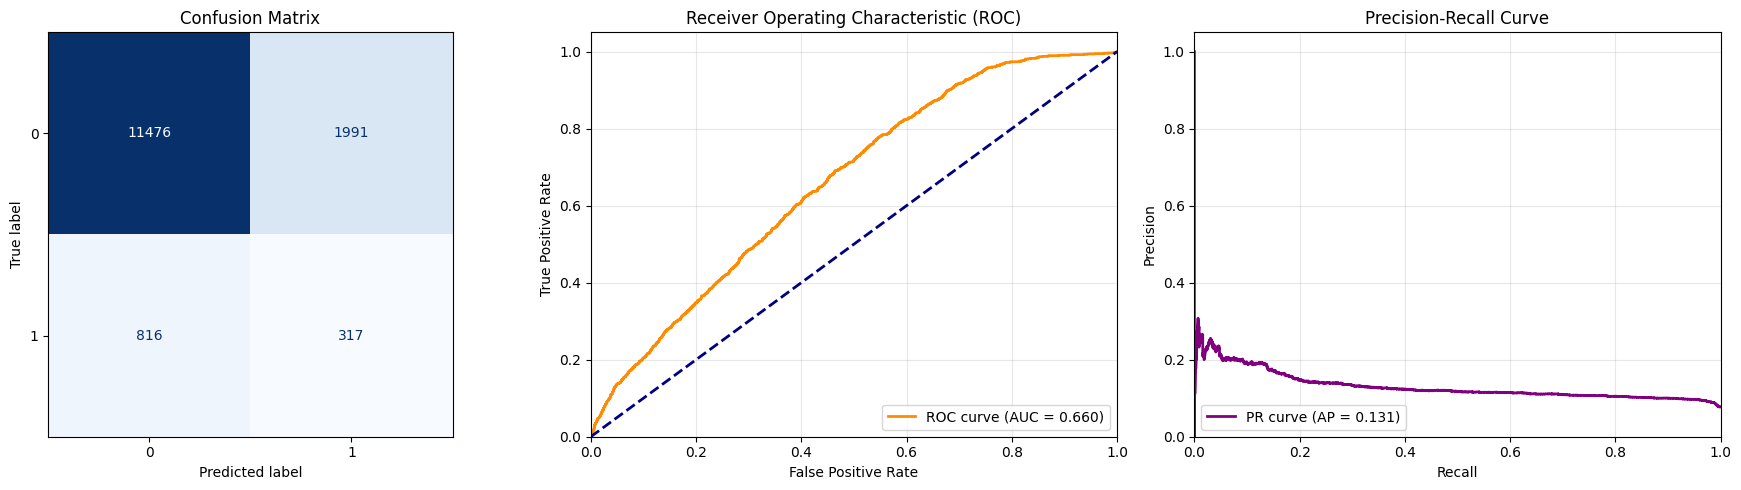


Plots displayed above and saved successfully to: /content/MLP_Evaluation_Plots.pdf


In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

print("--- 1. Classification Report ---")
y_pred = mlp_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Get probabilities for the ROC and PR curves
# Assuming binary classification, we take the probabilities of the positive class (index 1)
y_prob = mlp_model.predict_proba(X_test)[:, 1]

# Set up a grid to display all three plots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 2. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

# --- 3. ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

# --- 4. Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {pr_auc:.3f})')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc="lower left")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

# Save locally to Colab (bypassing Google Drive)
save_path = '/content/MLP_Evaluation_Plots.pdf'
plt.savefig(save_path, format='pdf', bbox_inches='tight')

# Display the plots right here in the notebook
plt.show()

print(f"\nPlots displayed above and saved successfully to: {save_path}")

--- MLP Advanced Metrics ---
Log Loss: 0.4471
Matthews Correlation Coefficient (MCC): 0.0968



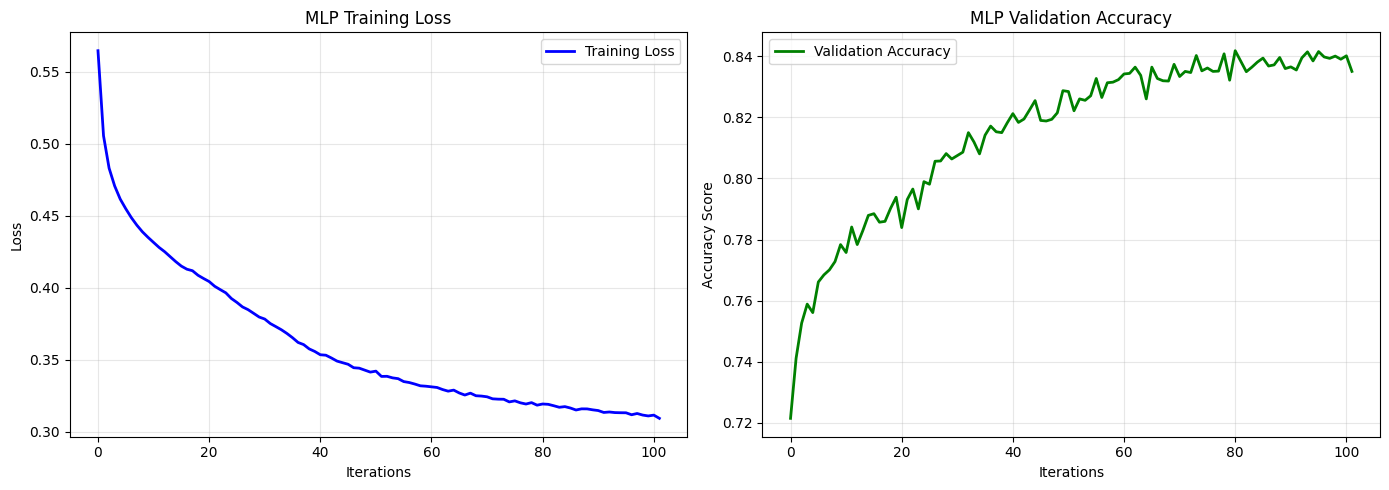


Curves displayed above and saved successfully to: /content/MLP_Learning_Curves.pdf


In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, matthews_corrcoef

# ---------------------------------------------------------
# 1. Calculate Log Loss & MCC
# ---------------------------------------------------------
y_pred = mlp_model.predict(X_test)
y_prob = mlp_model.predict_proba(X_test)

mlp_log_loss = log_loss(y_test, y_prob)
mlp_mcc = matthews_corrcoef(y_test, y_pred)

print("--- MLP Advanced Metrics ---")
print(f"Log Loss: {mlp_log_loss:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mlp_mcc:.4f}\n")

# ---------------------------------------------------------
# 2. Extract Classifier from Pipeline
# ---------------------------------------------------------
# If your mlp_model is a pipeline, we need to extract the actual neural network step.
# (If it throws an error here, change 'classifier' to whatever name you used in your Pipeline)
try:
    # Look for common pipeline step names
    if 'classifier' in mlp_model.named_steps:
        clf = mlp_model.named_steps['classifier']
    elif 'mlp' in mlp_model.named_steps:
        clf = mlp_model.named_steps['mlp']
    else:
        # Grabs the very last step in the pipeline, which is usually the model
        clf = mlp_model.steps[-1][1]
except AttributeError:
    # If it's not a pipeline, just use the model directly
    clf = mlp_model

# ---------------------------------------------------------
# 3. Plot the Learning Curves
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot A: Training Loss Curve ---
if hasattr(clf, 'loss_curve_'):
    axes[0].plot(clf.loss_curve_, label='Training Loss', color='blue', lw=2)
    axes[0].set_title("MLP Training Loss")
    axes[0].set_xlabel("Iterations")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "Loss curve not available", ha='center', va='center')
    axes[0].set_title("MLP Training Loss")

# --- Plot B: Validation Accuracy Curve ---
# This will only plot if you used early_stopping=True during training
if hasattr(clf, 'validation_scores_') and clf.validation_scores_:
    axes[1].plot(clf.validation_scores_, label='Validation Accuracy', color='green', lw=2)
    axes[1].set_title("MLP Validation Accuracy")
    axes[1].set_xlabel("Iterations")
    axes[1].set_ylabel("Accuracy Score")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "Validation scores not available\n(Requires early_stopping=True in model setup)",
                 ha='center', va='center', fontsize=10)
    axes[1].set_title("MLP Validation Accuracy")

plt.tight_layout()

# Save locally to Colab
save_path = '/content/MLP_Learning_Curves.pdf'
plt.savefig(save_path, format='pdf', bbox_inches='tight')

# Show the plots
plt.show()

print(f"\nCurves displayed above and saved successfully to: {save_path}")

Defining and training LightGBM to capture epoch-by-epoch history...
[LightGBM] [Info] Number of positive: 53867, number of negative: 53867
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028785 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5570
[LightGBM] [Info] Number of data points in the train set: 107734, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


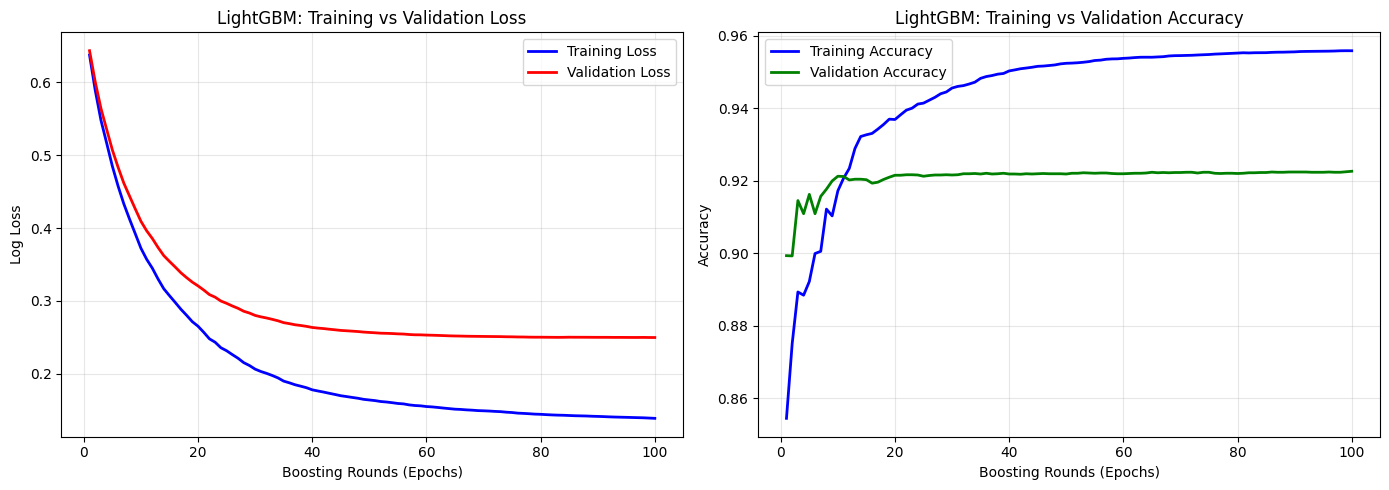


Curves displayed above and saved successfully to: /content/LGBM_Learning_Curves.pdf


In [47]:
import lightgbm as lgb
import matplotlib.pyplot as plt

print("Defining and training LightGBM to capture epoch-by-epoch history...")

# THE FIX: Explicitly create the LightGBM model first so Colab knows what it is!
lgb_model = lgb.LGBMClassifier(random_state=42)

# 1. Fit the model while passing the evaluation sets
# We use 'binary_logloss' for Loss, and 'binary_error' (which is 1 - accuracy)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_names=['Training', 'Validation'],
    eval_metric=['binary_logloss', 'binary_error']
)

# 2. Extract the history
results = lgb_model.evals_result_

# LightGBM tracks error. We convert it to Accuracy: (1 - error)
train_acc = [1 - x for x in results['Training']['binary_error']]
val_acc = [1 - x for x in results['Validation']['binary_error']]

train_loss = results['Training']['binary_logloss']
val_loss = results['Validation']['binary_logloss']
epochs = range(1, len(train_loss) + 1)

# 3. Plot the Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot A: Train vs Validation Loss ---
axes[0].plot(epochs, train_loss, label='Training Loss', color='blue', lw=2)
axes[0].plot(epochs, val_loss, label='Validation Loss', color='red', lw=2)
axes[0].set_title('LightGBM: Training vs Validation Loss')
axes[0].set_xlabel('Boosting Rounds (Epochs)')
axes[0].set_ylabel('Log Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot B: Train vs Validation Accuracy ---
axes[1].plot(epochs, train_acc, label='Training Accuracy', color='blue', lw=2)
axes[1].plot(epochs, val_acc, label='Validation Accuracy', color='green', lw=2)
axes[1].set_title('LightGBM: Training vs Validation Accuracy')
axes[1].set_xlabel('Boosting Rounds (Epochs)')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Save locally to Colab (bypassing Google Drive)
save_path = '/content/LGBM_Learning_Curves.pdf'
plt.savefig(save_path, format='pdf', bbox_inches='tight')

# Display the plots
plt.show()

print(f"\nCurves displayed above and saved successfully to: {save_path}")